# EDA


## 1) Load the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

df=pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Phase 1: Business understanding

The Superstore dataset can answer questions such as:
- Which products and categories generate the most revenue?
- Which regions and states perform best?
- Which customers and segments are most valuable?
- How do sales evolve over time?
- How efficient is shipping across modes and regions?

This helps with inventory planning, sales strategy, and operational improvement.


## Phase 2: Initial data inspection

### Question 1

How many rows and columns are in the dataset?

In [2]:
df.shape

(9800, 18)

### Question 2

What does the head and tail of the dataset look like?

In [3]:
df.head()

df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


### Question 3

What are the data types and structure of each column?

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

### Question 4

How many missing values are present in each column?

In [5]:
df.isnull().sum().sort_values(ascending=False)

,0
Postal Code,11
Row ID,0
Order ID,0
Order Date,0
Ship Mode,0
Ship Date,0
Customer Name,0
Segment,0
Country,0
Customer ID,0


### Question 5

How many duplicate rows are present?

In [6]:
df.duplicated().sum()

np.int64(0)

## Phase 3: Data cleaning and preparation

### Cleaning checklist
We should:
- standardize column names
- parse date columns
- drop exact duplicate rows
- compute shipping duration
- check for strange values such as negative sales or negative delivery time


In [8]:
# Create a working copy
data = df.copy()

# Standardize column names
data.columns = [c.strip().lower().replace(" ", "_") for c in data.columns]

# Parse dates
data["order_date"] = pd.to_datetime(data["order_date"],dayfirst=True)
data["ship_date"] = pd.to_datetime(data["ship_date"],dayfirst=True)

# Remove exact duplicates
before = len(data)
data = data.drop_duplicates().reset_index(drop=True)
after = len(data)

# Feature: shipping duration in days
data["shipping_days"] = (data["ship_date"] - data["order_date"]).dt.days

before, after, data.head()

(9800,
 9800,
    row_id        order_id order_date  ship_date       ship_mode customer_id  \
 0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
 1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
 2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
 3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
 4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
 
      customer_name    segment        country             city       state  \
 0      Claire Gute   Consumer  United States        Henderson    Kentucky   
 1      Claire Gute   Consumer  United States        Henderson    Kentucky   
 2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
 3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
 4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
 
    postal_code region       produ

In [9]:
sanity_report = {
    "rows": len(data),
    "negative_sales": int((data["sales"] < 0).sum()),
    "zero_sales": int((data["sales"] == 0).sum()),
    "negative_shipping_days": int((data["shipping_days"] < 0).sum()),
    "max_shipping_days": int(data["shipping_days"].max()),
}
pd.Series(sanity_report)

,0
rows,9800
negative_sales,0
zero_sales,0
negative_shipping_days,0
max_shipping_days,7


## Phase 4: Univariate analysis

### Question 6

What is the distribution of sales?

In [10]:
data["sales"].describe()

,sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


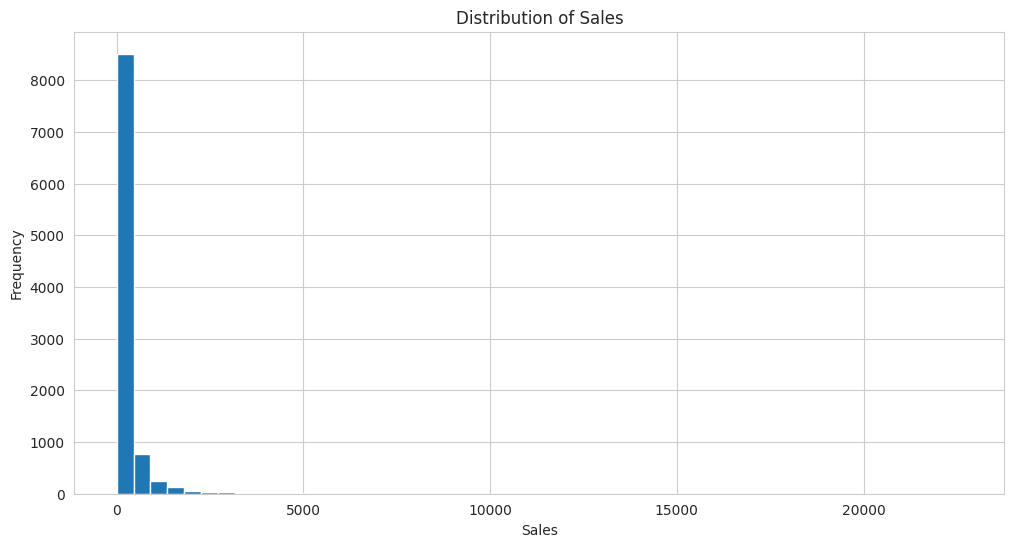

In [11]:
plt.hist(data["sales"], bins=50)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

### Question 7

Which ship mode is used most often?

In [12]:
data["ship_mode"].value_counts()

,count
ship_mode,
Standard Class,5859
Second Class,1902
First Class,1501
Same Day,538


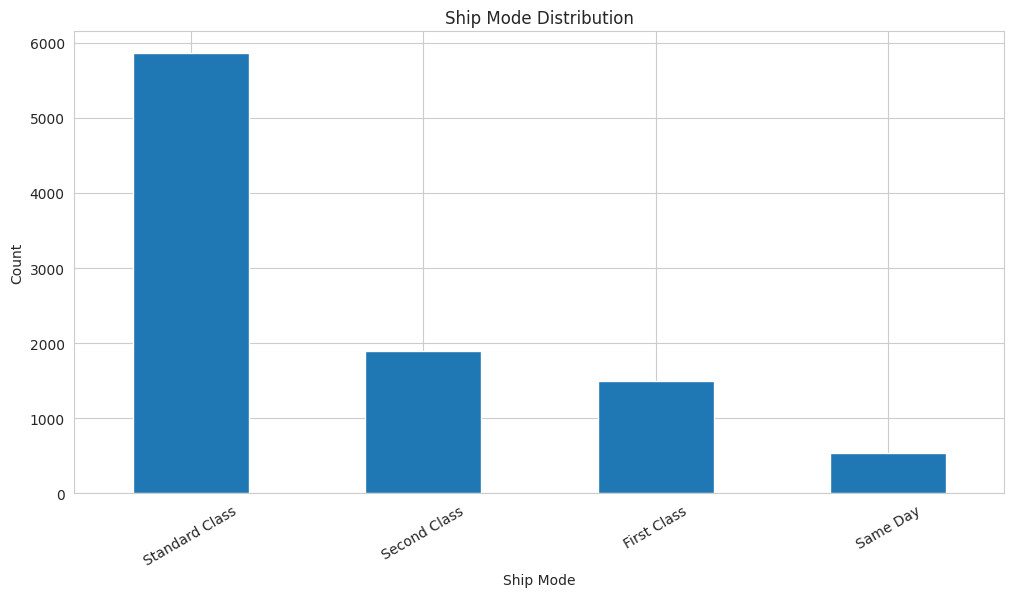

In [13]:
data["ship_mode"].value_counts().plot(kind="bar")
plt.title("Ship Mode Distribution")
plt.xlabel("Ship Mode")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

### Question 8

What is the distribution of customer segments?

In [14]:
data["segment"].value_counts()

,count
segment,
Consumer,5101
Corporate,2953
Home Office,1746


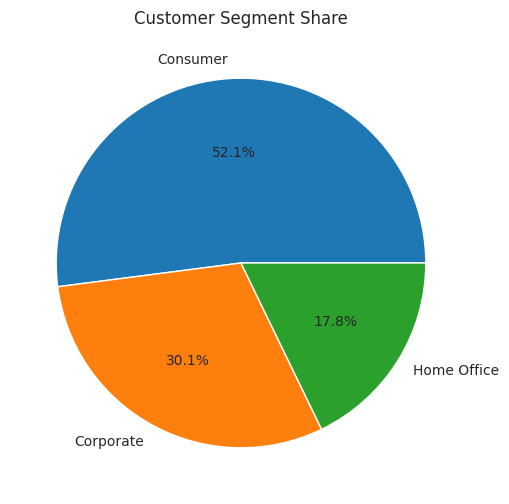

In [15]:
data["segment"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Customer Segment Share")
plt.ylabel("")
plt.show()

### Question 9

Which product categories appear most often?

In [16]:
data["category"].value_counts()

,count
category,
Office Supplies,5909
Furniture,2078
Technology,1813


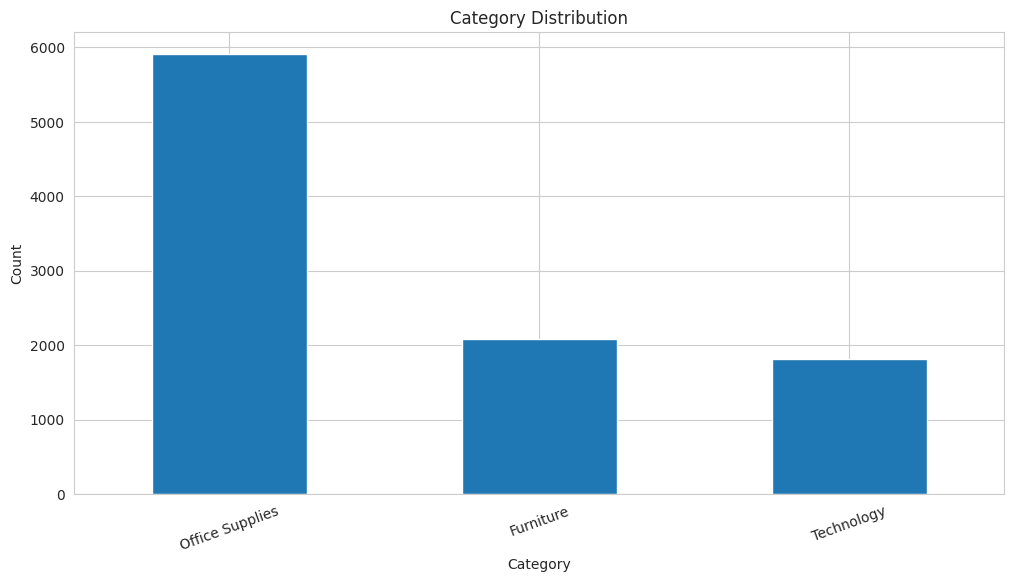

In [17]:
data["category"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

### Question 10

Which sub-categories appear most often?

In [20]:
data.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'shipping_days'],
      dtype='object')

In [23]:
data["sub-category"].value_counts().head(15)

,count
sub-category,
Binders,1492
Paper,1338
Furnishings,931
Phones,876
Storage,832
Art,785
Accessories,756
Chairs,607
Appliances,459


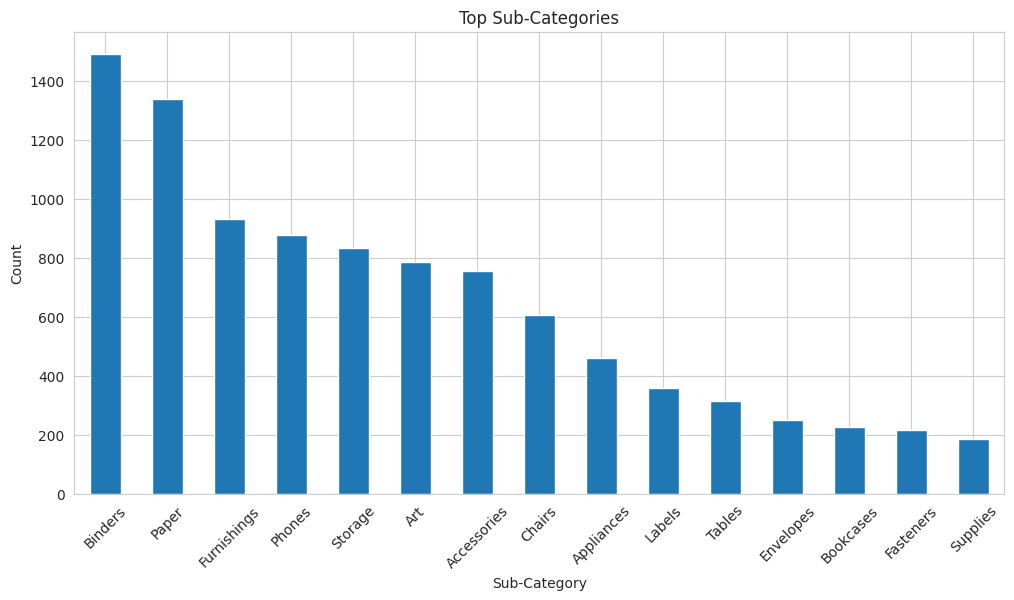

In [24]:
data["sub-category"].value_counts().head(15).plot(kind="bar")
plt.title("Top Sub-Categories")
plt.xlabel("Sub-Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Question 11

Which states have the highest number of orders?

In [25]:
data["state"].value_counts().head(10)

,count
state,
California,1946
New York,1097
Texas,973
Pennsylvania,582
Washington,504
Illinois,483
Ohio,454
Florida,373
Michigan,253


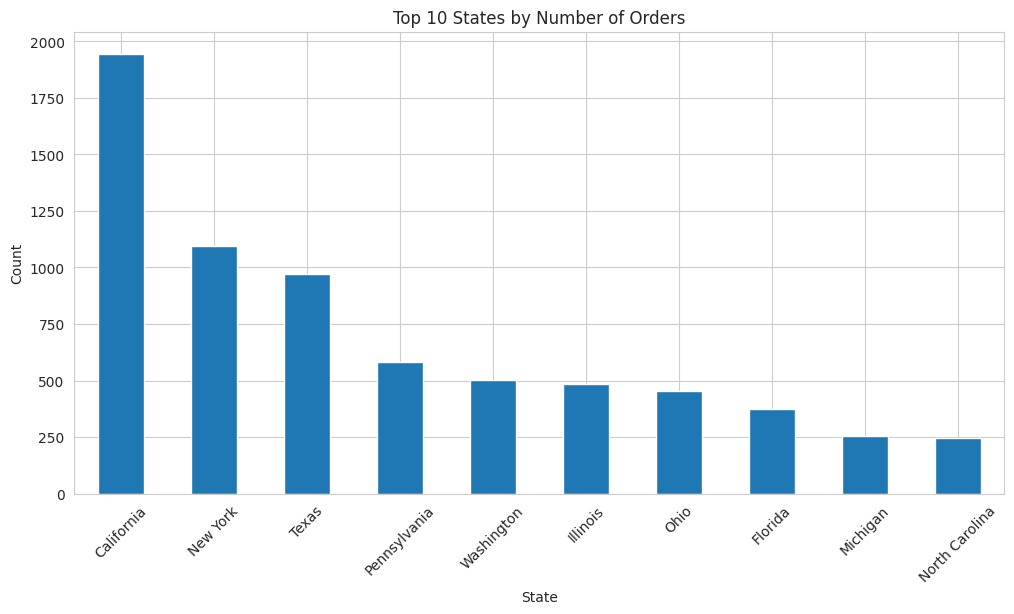

In [26]:
data["state"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 States by Number of Orders")
plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Question 12

Which cities have the highest number of orders?

In [27]:
data["city"].value_counts().head(10)

,count
city,
New York City,891
Los Angeles,728
Philadelphia,532
San Francisco,500
Seattle,426
Houston,374
Chicago,308
Columbus,221
San Diego,170


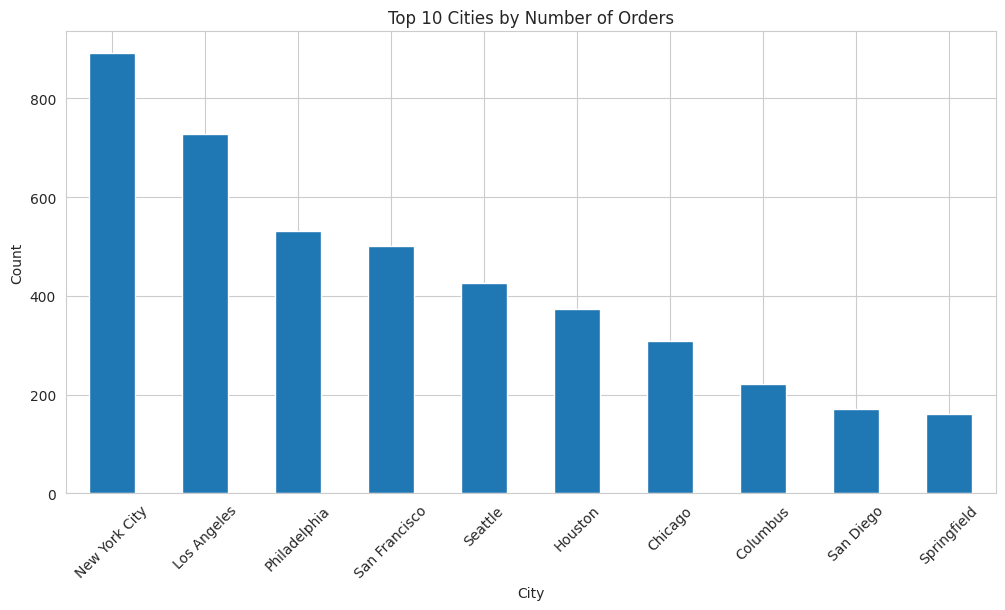

In [28]:
data["city"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Cities by Number of Orders")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Phase 5: Outlier analysis

### Question 13
Are there extreme sales values that may distort averages?


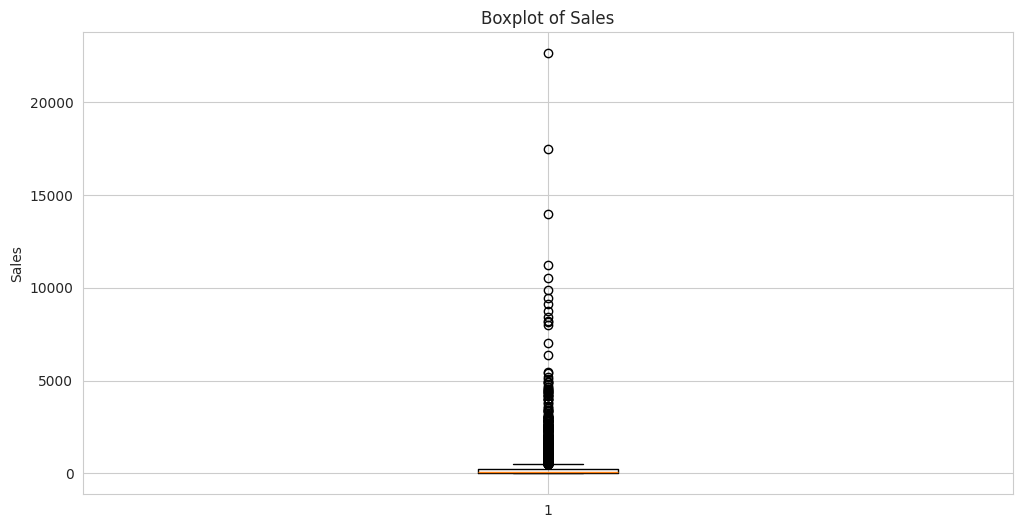

In [29]:
plt.boxplot(data["sales"])
plt.title("Boxplot of Sales")
plt.ylabel("Sales")
plt.show()

In [30]:

q1 = data["sales"].quantile(0.25)
q3 = data["sales"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = data[(data["sales"] < lower) | (data["sales"] > upper)]

pd.Series({
    "Q1": q1,
    "Q3": q3,
    "IQR": iqr,
    "Lower Bound": lower,
    "Upper Bound": upper,
    "Outlier Count": len(outliers)
})

,0
Q1,17.2480
Q3,210.6050
IQR,193.3570
Lower Bound,-272.7875
Upper Bound,500.6405
Outlier Count,1145.0000


## Phase 6: Bivariate analysis

### Question 14

How do sales vary by category?

In [31]:
data.groupby("category")["sales"].sum().sort_values(ascending=False)

,sales
category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


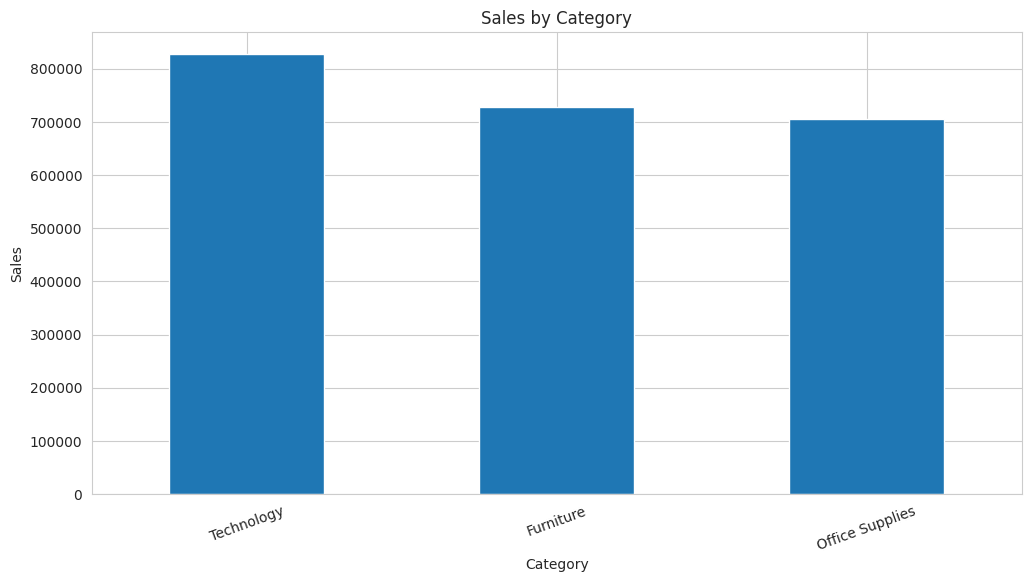

In [32]:
data.groupby("category")["sales"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=20)
plt.show()

### Question 15

How do sales vary by sub-category?

In [34]:
data.groupby("sub-category")["sales"].sum().sort_values(ascending=False).head(10)

,sales
sub-category,
Phones,327782.4480
Chairs,322822.7310
Storage,219343.3920
Tables,202810.6280
Binders,200028.7850
Machines,189238.6310
Accessories,164186.7000
Copiers,146248.0940
Bookcases,113813.1987


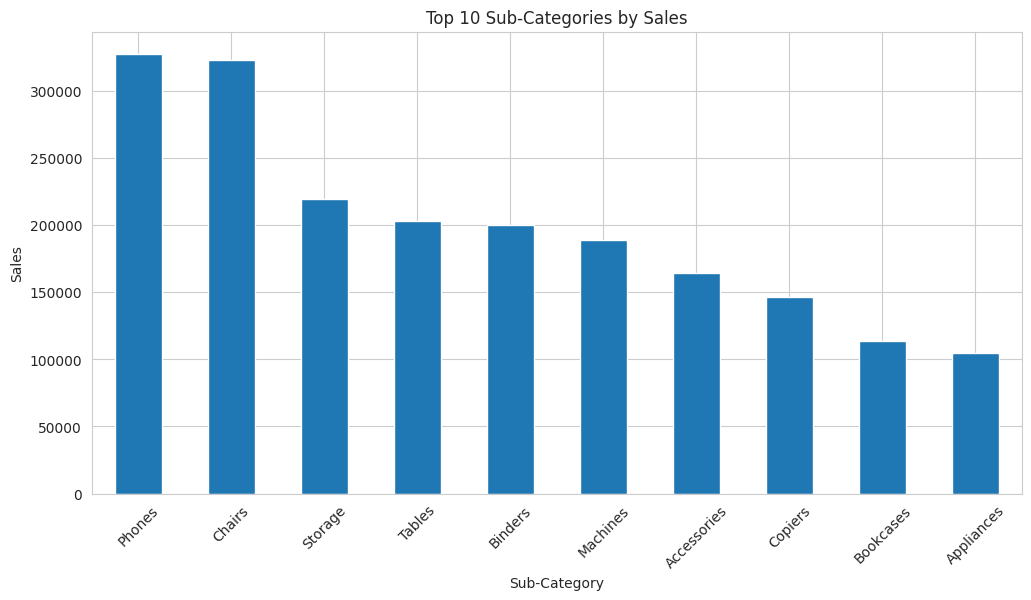

In [36]:
data.groupby("sub-category")["sales"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

### Question 16

How do sales differ across customer segments?

In [37]:
data.groupby("segment")["sales"].sum().sort_values(ascending=False)

,sales
segment,
Consumer,1.148061e+06
Corporate,6.884941e+05
Home Office,4.249822e+05


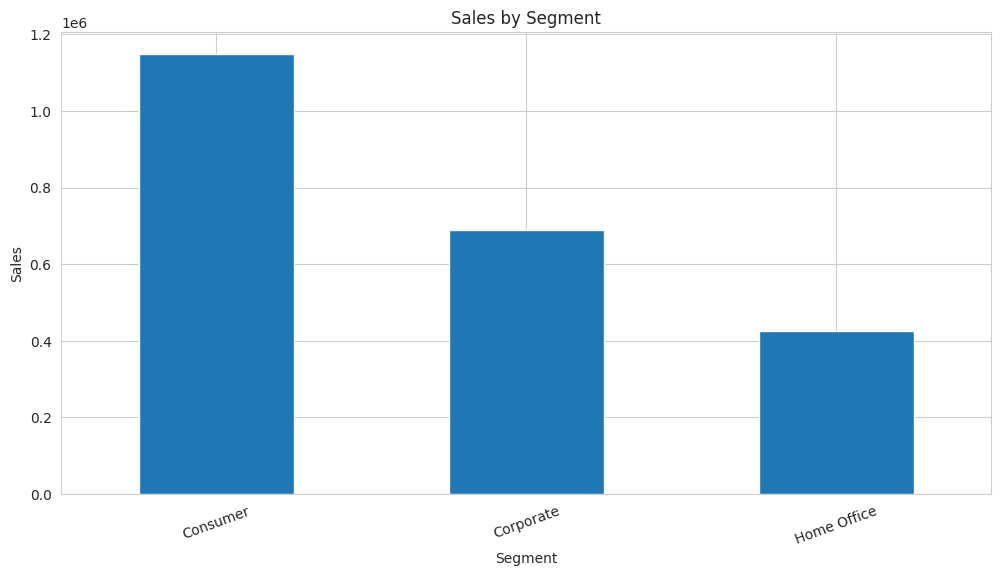

In [38]:
data.groupby("segment")["sales"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.xticks(rotation=20)
plt.show()

### Question 17

How do sales differ across regions?

In [39]:
data.groupby("region")["sales"].sum().sort_values(ascending=False)

,sales
region,
West,710219.6845
East,669518.7260
Central,492646.9132
South,389151.4590


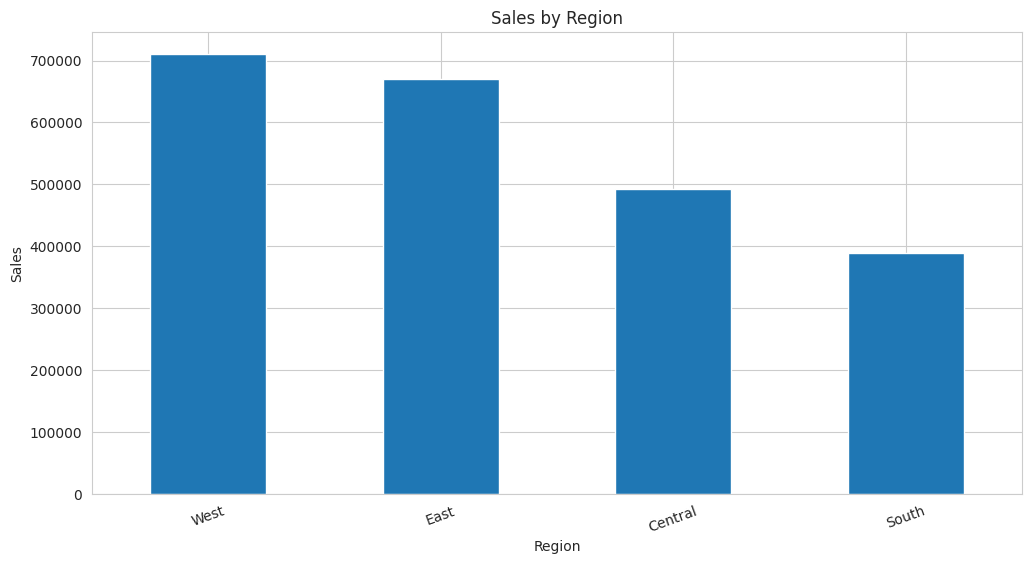

In [40]:
data.groupby("region")["sales"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=20)
plt.show()

### Question 18

How do sales differ across ship modes?

In [41]:
data.groupby("ship_mode")["sales"].sum().sort_values(ascending=False)

,sales
ship_mode,
Standard Class,1.340831e+06
Second Class,4.499142e+05
First Class,3.455723e+05
Same Day,1.252190e+05


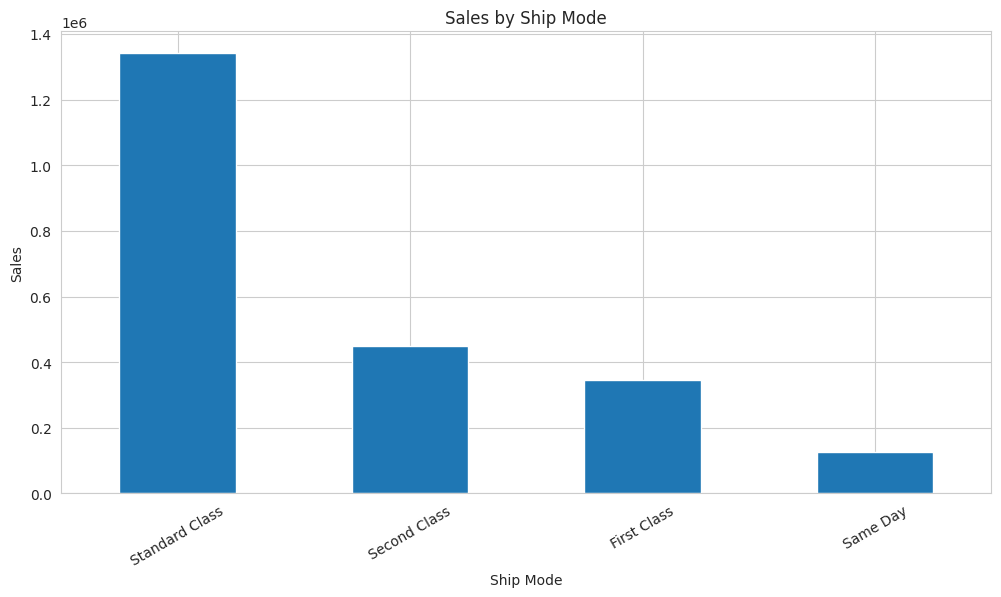

In [42]:
data.groupby("ship_mode")["sales"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.show()

### Question 19

Which states generate the highest sales?

In [43]:
data.groupby("state")["sales"].sum().sort_values(ascending=False).head(10)

,sales
state,
California,446306.4635
New York,306361.1470
Texas,168572.5322
Washington,135206.8500
Pennsylvania,116276.6500
Florida,88436.5320
Illinois,79236.5170
Michigan,76136.0740
Ohio,75130.3500


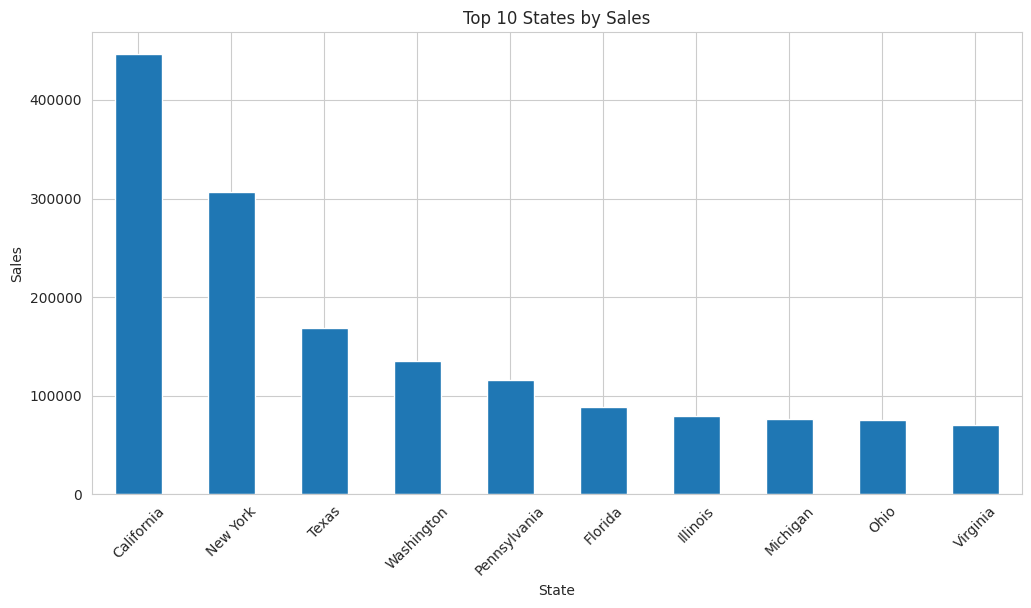

In [44]:
data.groupby("state")["sales"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

### Question 20

Which cities generate the highest sales?

In [45]:
data.groupby("city")["sales"].sum().sort_values(ascending=False).head(10)

,sales
city,
New York City,252462.5470
Los Angeles,173420.1810
Seattle,116106.3220
San Francisco,109041.1200
Philadelphia,108841.7490
Houston,63956.1428
Chicago,47820.1330
San Diego,47521.0290
Jacksonville,44713.1830


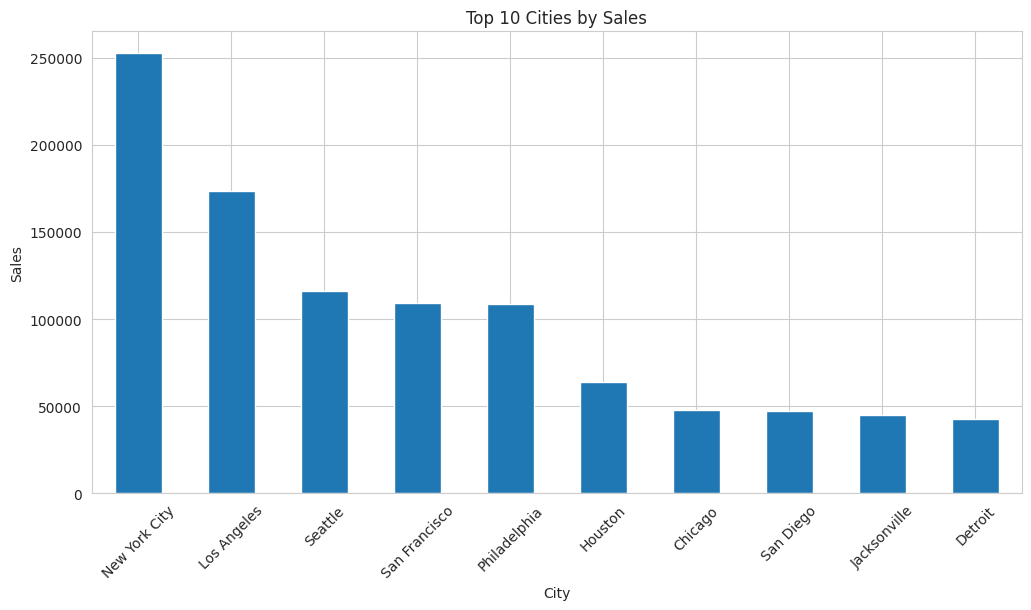

In [46]:
data.groupby("city")["sales"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

## Phase 7: Time-series analysis

### Missing in the first draft, but important for retail analysis
We also need to inspect:
- monthly sales trend
- yearly sales trend
- quarterly sales trend
- order volume over time
- seasonal patterns by month


In [47]:
data["order_year"] = data["order_date"].dt.year
data["order_month"] = data["order_date"].dt.month
data["order_month_name"] = data["order_date"].dt.month_name()
data["order_quarter"] = data["order_date"].dt.quarter
data["order_day_name"] = data["order_date"].dt.day_name()

monthly_sales = data.groupby(data["order_date"].dt.to_period("M"))["sales"].sum()
monthly_orders = data.groupby(data["order_date"].dt.to_period("M"))["order_id"].count()

monthly_sales.head(), monthly_orders.head()

(order_date
 2015-01    14205.707
 2015-02     4519.892
 2015-03    55205.797
 2015-04    27906.855
 2015-05    23644.303
 Freq: M, Name: sales, dtype: float64,
 order_date
 2015-01     77
 2015-02     46
 2015-03    154
 2015-04    130
 2015-05    121
 Freq: M, Name: order_id, dtype: int64)

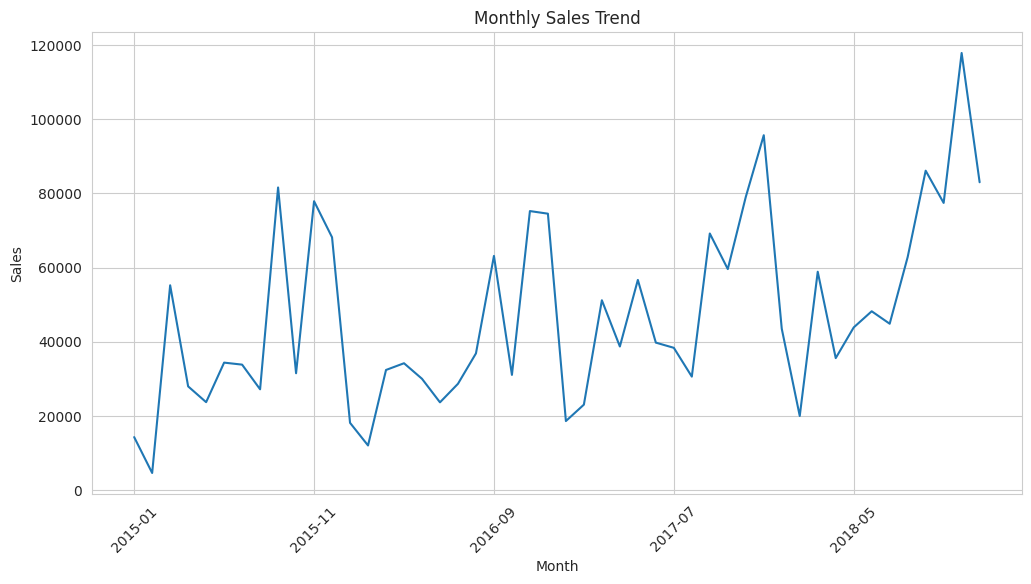

In [48]:
monthly_sales.index = monthly_sales.index.astype(str)
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

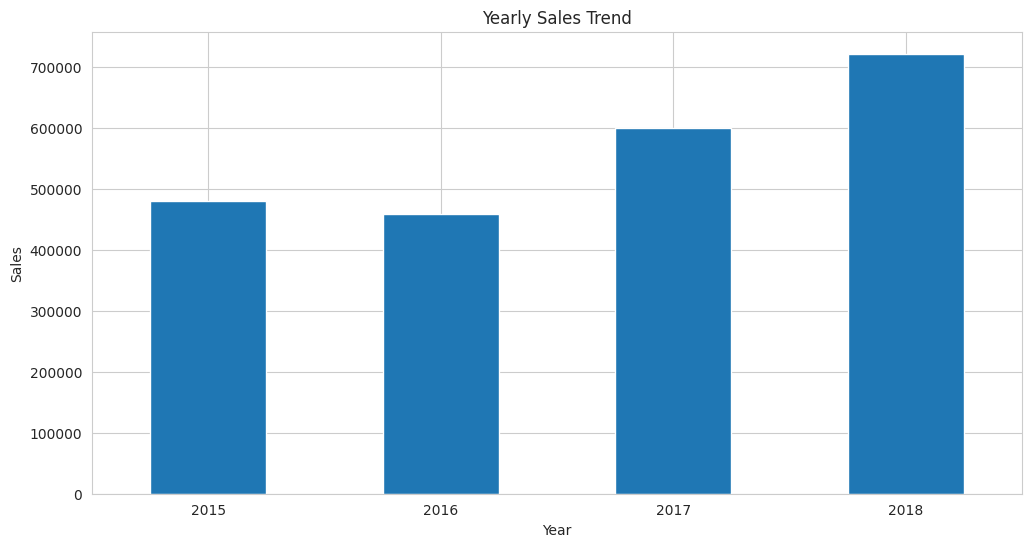

In [49]:
data.groupby("order_year")["sales"].sum().plot(kind="bar")
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

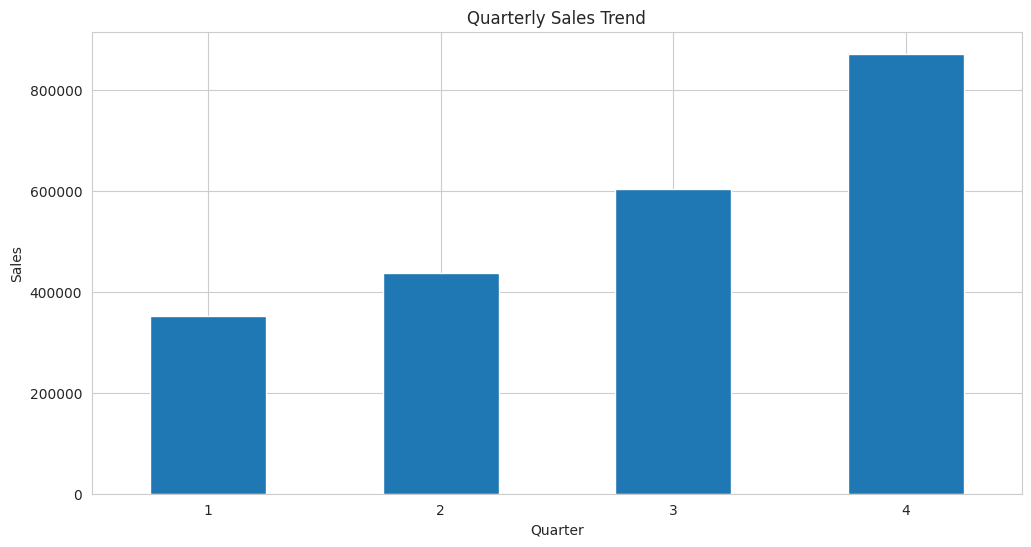

In [50]:
data.groupby("order_quarter")["sales"].sum().plot(kind="bar")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

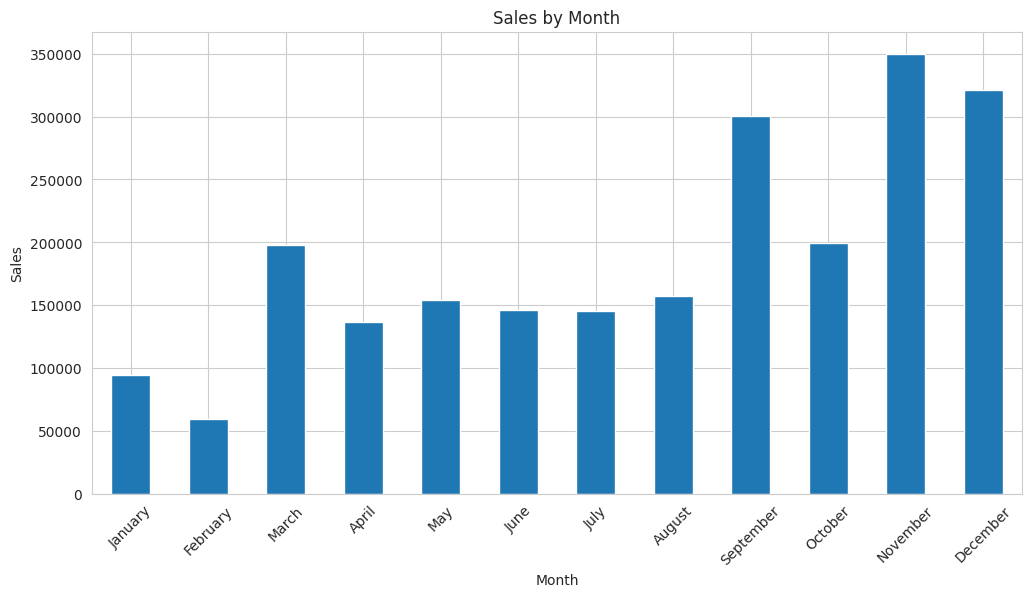

In [51]:
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
sales_by_month = data.groupby("order_month_name")["sales"].sum().reindex(month_order)

sales_by_month.plot(kind="bar")
plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

## Phase 8: Multivariate analysis

### Question 21
How do category and region interact with sales?


In [52]:
pivot_cat_region = pd.pivot_table(
    data,
    values="sales",
    index="category",
    columns="region",
    aggfunc="sum",
    fill_value=0
)
pivot_cat_region

region,Central,East,South,West
category,,,,
Furniture,160317.4622,206461.388,116531.480,245348.2455
Office Supplies,163590.2430,199940.811,124424.771,217466.5090
Technology,168739.2080,263116.527,148195.208,247404.9300


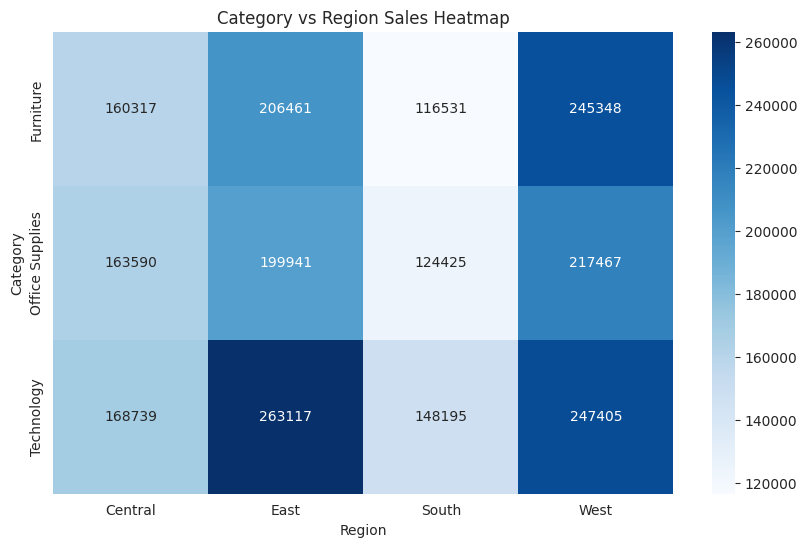

In [53]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_cat_region, annot=True, fmt=".0f", cmap="Blues")
plt.title("Category vs Region Sales Heatmap")
plt.xlabel("Region")
plt.ylabel("Category")
plt.show()

### Question 22
Which sub-categories perform best across categories?


In [54]:
pivot_cat_sub = pd.pivot_table(
    data,
    values="sales",
    index="category",
    columns="sub_category",
    aggfunc="sum",
    fill_value=0
)
pivot_cat_sub

KeyError: 'sub_category'

In [55]:
plt.figure(figsize=(16, 6))
sns.heatmap(pivot_cat_sub, cmap="YlGnBu")
plt.title("Category vs Sub-Category Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Category")
plt.xticks(rotation=45, ha="right")
plt.show()

NameError: name 'pivot_cat_sub' is not defined

<Figure size 1600x600 with 0 Axes>

### Question 23
Which regions prefer which ship modes?


In [56]:
pivot_region_ship = pd.pivot_table(
    data,
    values="sales",
    index="region",
    columns="ship_mode",
    aggfunc="sum",
    fill_value=0
)
pivot_region_ship

ship_mode,First Class,Same Day,Second Class,Standard Class
region,,,,
Central,58057.2978,20105.922,97605.7134,316877.9800
East,110436.6930,43316.464,115108.2580,400657.3110
South,49045.9160,21017.173,93434.5365,225653.8335
West,128032.3505,40779.480,143765.6715,397642.1825


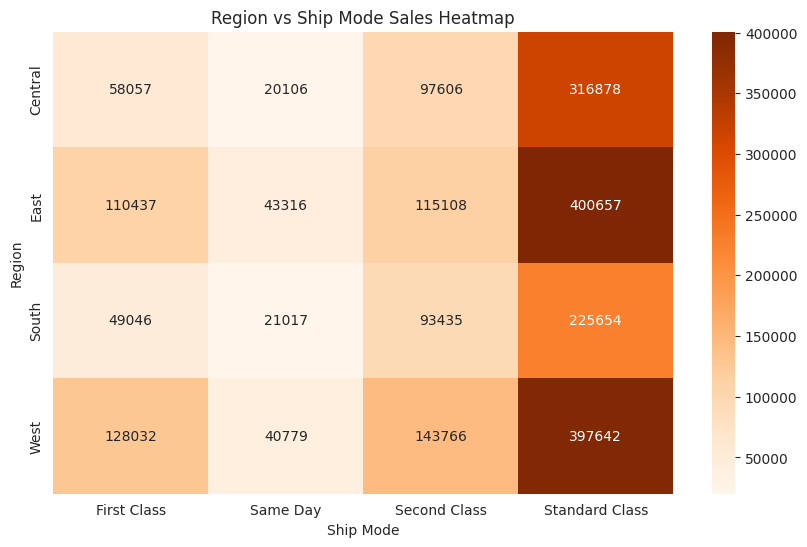

In [57]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_region_ship, annot=True, fmt=".0f", cmap="Oranges")
plt.title("Region vs Ship Mode Sales Heatmap")
plt.xlabel("Ship Mode")
plt.ylabel("Region")
plt.show()

## Phase 9: Customer and product analysis

These sections were missing from the first draft and are important for a complete retail workbook.


In [58]:
top_customers = data.groupby(["customer_id", "customer_name"])["sales"].sum().sort_values(ascending=False).head(10)
top_customers

,,sales
customer_id,customer_name,
SM-20320,Sean Miller,25043.050
TC-20980,Tamara Chand,19052.218
RB-19360,Raymond Buch,15117.339
TA-21385,Tom Ashbrook,14595.620
AB-10105,Adrian Barton,14473.571
KL-16645,Ken Lonsdale,14175.229
SC-20095,Sanjit Chand,14142.334
HL-15040,Hunter Lopez,12873.298
SE-20110,Sanjit Engle,12209.438


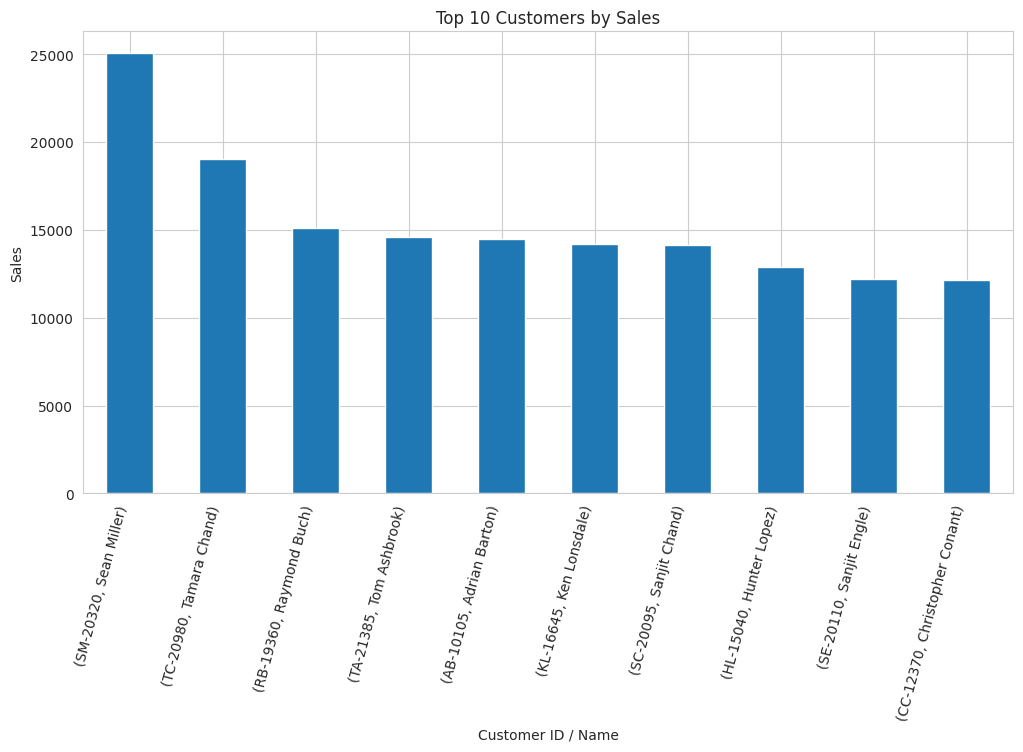

In [59]:
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer ID / Name")
plt.ylabel("Sales")
plt.xticks(rotation=75, ha="right")
plt.show()

In [60]:
top_products = data.groupby(["product_id", "product_name"])["sales"].sum().sort_values(ascending=False).head(10)
top_products

,,sales
product_id,product_name,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,21870.576
OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,19823.479
OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068


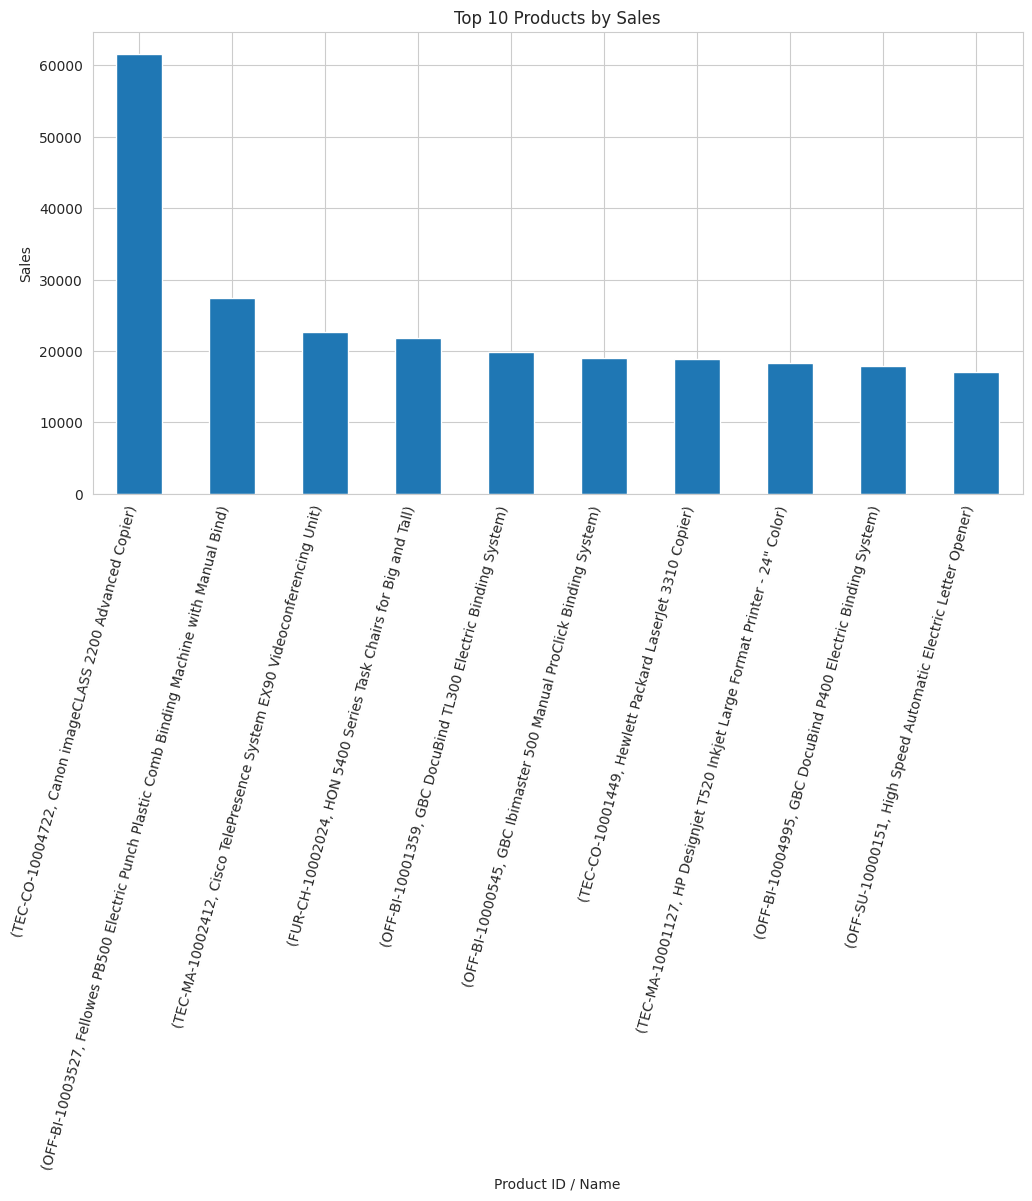

In [61]:
top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product ID / Name")
plt.ylabel("Sales")
plt.xticks(rotation=75, ha="right")
plt.show()

In [62]:
segment_category = pd.pivot_table(
    data,
    values="sales",
    index="segment",
    columns="category",
    aggfunc="sum",
    fill_value=0
)
segment_category

category,Furniture,Office Supplies,Technology
segment,,,
Consumer,387696.2580,359352.608,401011.665
Corporate,220321.7018,224130.536,244041.837
Home Office,120640.6159,121939.190,182402.371


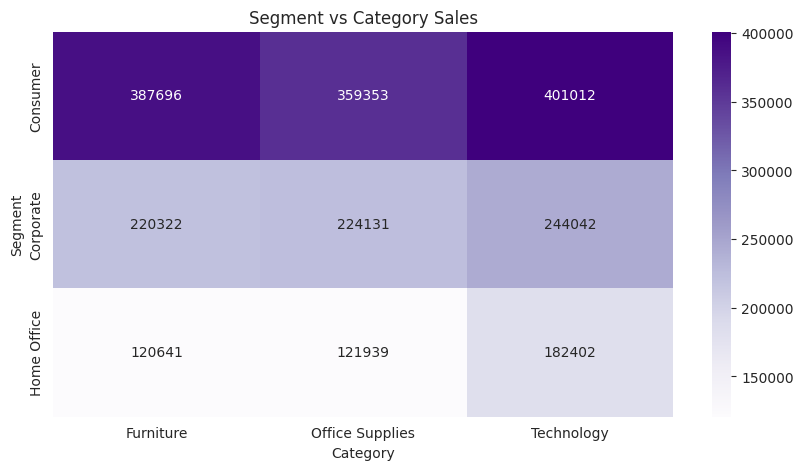

In [63]:
plt.figure(figsize=(10, 5))
sns.heatmap(segment_category, annot=True, fmt=".0f", cmap="Purples")
plt.title("Segment vs Category Sales")
plt.xlabel("Category")
plt.ylabel("Segment")
plt.show()

## Phase 10: Feature engineering

### New engineered features
- order year
- order month
- order quarter
- order day name
- shipping days
- sales per shipping day
- sales band


In [64]:
data["sales_band"] = pd.cut(
    data["sales"],
    bins=[-np.inf, 50, 200, 500, 1000, np.inf],
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

data["sales_per_shipping_day"] = data["sales"] / data["shipping_days"].replace(0, np.nan)

data[[
    "order_date", "ship_date", "shipping_days",
    "order_year", "order_month", "order_quarter",
    "order_day_name", "sales_band", "sales_per_shipping_day"
]].head()

,order_date,ship_date,shipping_days,order_year,order_month,order_quarter,order_day_name,sales_band,sales_per_shipping_day
0,2017-11-08,2017-11-11,3,2017,11,4,Wednesday,Medium,87.320000
1,2017-11-08,2017-11-11,3,2017,11,4,Wednesday,High,243.980000
2,2017-06-12,2017-06-16,4,2017,6,2,Monday,Very Low,3.655000
3,2016-10-11,2016-10-18,7,2016,10,4,Tuesday,High,136.796786
4,2016-10-11,2016-10-18,7,2016,10,4,Tuesday,Very Low,3.195429


In [65]:
data["sales_band"].value_counts().sort_index()

,count
sales_band,
Very Low,4757
Low,2506
Medium,1391
High,684
Very High,462


In [66]:
data["shipping_days"].describe()

,shipping_days
count,9800.000000
mean,3.961122
std,1.749614
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000


In [67]:
data.groupby("ship_mode")["shipping_days"].mean().sort_values()

,shipping_days
ship_mode,
Same Day,0.044610
First Class,2.179214
Second Class,3.249211
Standard Class,5.008363


In [68]:
data.groupby("region")["shipping_days"].mean().sort_values()

,shipping_days
region,
East,3.910233
West,3.930255
South,3.961202
Central,4.065876


## Phase 11: Correlation and numeric relationships

In [69]:
numeric_cols = data.select_dtypes(include="number").columns
corr = data[numeric_cols].corr()
corr

,row_id,postal_code,sales,shipping_days,order_year,order_month,order_quarter,sales_per_shipping_day
row_id,1.000000,0.013645,0.001151,0.000976,0.019065,-0.014809,-0.016724,-0.004150
postal_code,0.013645,1.000000,-0.024067,-0.009443,0.006418,0.021685,0.023923,-0.005895
sales,0.001151,-0.024067,1.000000,-0.005712,-0.010624,-0.000134,-0.001434,0.862507
shipping_days,0.000976,-0.009443,-0.005712,1.000000,-0.024498,0.000210,0.004716,-0.167149
order_year,0.019065,0.006418,-0.010624,-0.024498,1.000000,-0.018278,-0.018515,-0.000177
order_month,-0.014809,0.021685,-0.000134,0.000210,-0.018278,1.000000,0.969299,-0.011380
order_quarter,-0.016724,0.023923,-0.001434,0.004716,-0.018515,0.969299,1.000000,-0.014155
sales_per_shipping_day,-0.004150,-0.005895,0.862507,-0.167149,-0.000177,-0.011380,-0.014155,1.000000


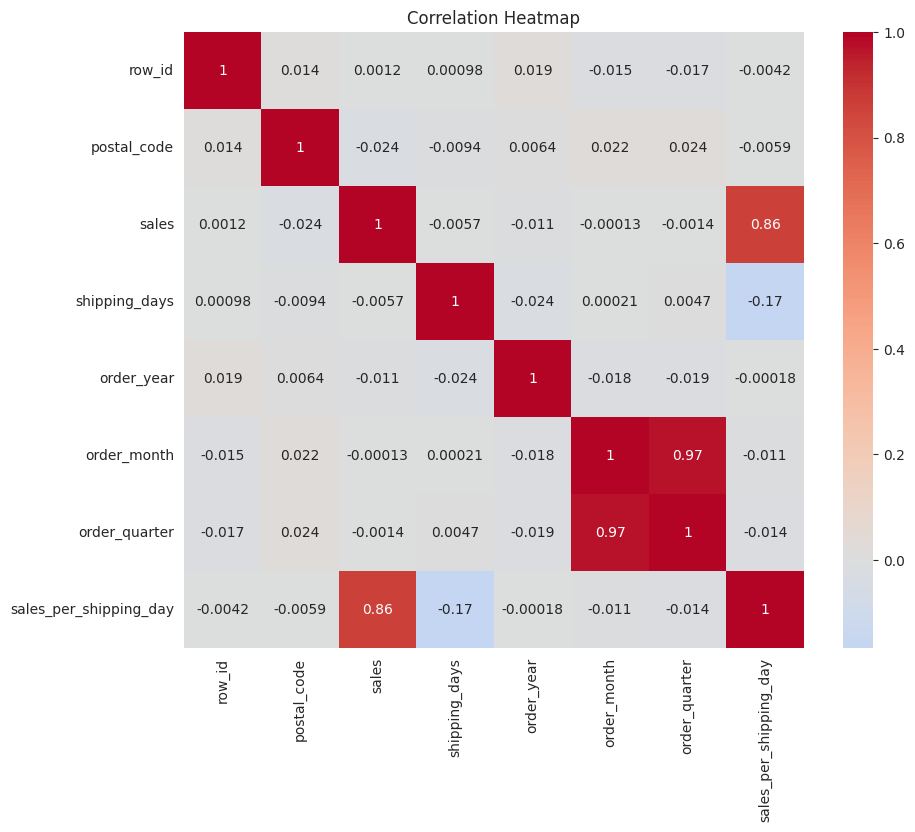

In [71]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## Phase 12: Executive summary

### Key findings to write after running the notebook
- Which category and sub-category lead sales
- Which region and state are strongest
- Which ship mode has the highest order volume
- Whether sales are concentrated in a few customers or products
- How sales change month by month and year by year
- Whether shipping time varies by region or ship mode

### Business recommendations
- focus inventory on top-performing categories and sub-categories
- target high-value regions and states with stronger campaigns
- review shipping performance by mode and region
- identify repeat customers and top products for loyalty strategies
- plan promotions around seasonal peaks in monthly sales
